# **MScFE 690: CapstoneProject**
## **Influence Diagram as A Decision-Making Tool for Factor Investing**
### Student Group: **11186**
#### Members:
1. **Vahid Nikoofard**
2. **Dipanshu Sharma**
3. **Rhesa Prabowo Budhidarmo**


In [ ]:
# installing the required packages

In [4]:
# importing the required packages and libraries

import io, os, sys, math, datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import openassetpricing as oap

import warnings 
warnings.filterwarnings('ignore')

/opt/anaconda3/envs/py312/lib/python3.12/site-packages/seaborn/_statistics.py:32: UserWarning: A NumPy version >=1.22.4 and <2.3.0 is required for this version of SciPy (detected version 2.3.1)
  from scipy.stats import gaussian_kde


In [5]:
# master project path
# base_path = "/Users/sharmadipanshu/Developer/MScFE 2509 Capstone/WQU_Capstone_Project/MScFE_WQU_Capstone_Project"
base_path = '../'
# defining subpaths
inputs_raw = f"{base_path}/inputs/raw"
inputs_clean = f"{base_path}/inputs/clean"
outputs_eda = f"{base_path}/outputs/eda"
meta_path = f"{base_path}/inputs/meta"

In [6]:
# defining the required custom functions

## **Step 1: Exploratory Data Analysis (EDA) / ETL (Extract, Transfom and Load)**

In [7]:
# initializing openap for downloading the dataset
openap = oap.OpenAP()
openap.list_port() 

┌─────────────────────────────────────────────────┬─────────────────────┐
│ CZ portfolio file                               │ Name for download   │
├─────────────────────────────────────────────────┼─────────────────────┤
│ PredictorAltPorts_Deciles.zip                   │ deciles_ew          │
│ PredictorAltPorts_DecilesVW.zip                 │ deciles_vw          │
│ PredictorAltPorts_LiqScreen_ME_gt_NYSE20pct.zip │ ex_nyse_p20_me      │
│ PredictorAltPorts_LiqScreen_NYSEonly.zip        │ nyse                │
│ PredictorAltPorts_LiqScreen_Price_gt_5.zip      │ ex_price5           │
│ PredictorAltPorts_Quintiles.zip                 │ quintiles_ew        │
│ PredictorAltPorts_QuintilesVW.zip               │ quintiles_vw        │
│ PredictorPortsFull.csv                          │ op                  │
└─────────────────────────────────────────────────┴─────────────────────┘


In [ ]:
# openap.dl_signal_doc('pandas') # to check the documentation of the pandas signal
# openap.dl_all_signals('pandas') # to check all the available signals in pandas format

In [9]:
# downloading the selected factors, 
# BM (Book-to-Market), Mom12m (12-month Momentum), Size (Market Equity), OP (Operating Profitability), Investment, IdioVol3F (idiosyncratic volatility residualized vs 3-factor model)
# using value-weighted quintile portfolios
factors = ['BM', 'Mom12m', 'Size', 'OperProf', 'Investment', 'IdioVol3F'] 
port_name = 'quintiles_vw'

osap_df = openap.dl_port(port_name, 'pandas', factors)
osap_df.head()


Data is downloaded: 7s


,signalname,port,date,ret,signallag,Nlong,Nshort
0,BM,01,1951-07-31,6.324465,-0.921486,65,0
1,BM,01,1951-08-31,4.121121,-0.919069,65,0
2,BM,01,1951-09-28,0.393433,-0.917030,65,0
3,BM,01,1951-10-31,-5.521909,-0.912968,65,0
4,BM,01,1951-11-30,0.624145,-0.910410,65,0


In [10]:
osap_df.port.unique()
# LS is the long-short portfolio, which can we used as factor returns directly

array(['01', '02', '03', '04', '05', 'LS'], dtype=object)

In [11]:
# filter for LS (long short) port and selected factors
mask = (osap_df['port'].astype(str).str.upper() == 'LS') & (osap_df['signalname'].isin(factors))
ls_df = osap_df.loc[mask, ['signalname', 'date', 'ret']].copy()

# pivot to wide: index=date, columns=signalname, values=ret
osap_factor_returns = ls_df.pivot(index='date', columns='signalname', values='ret')
osap_factor_returns.head()

signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1926-07-31,NaN,NaN,NaN,NaN,NaN,-3.193279
1926-08-31,NaN,3.337295,NaN,NaN,NaN,-0.347584
1926-09-30,NaN,2.434277,NaN,NaN,NaN,-2.532196
1926-10-30,NaN,3.838838,NaN,NaN,NaN,0.053298
1926-11-30,NaN,2.732623,NaN,NaN,NaN,-3.435825


In [12]:
# filtering the common period from where all factor return data is available 
start_date = osap_factor_returns.dropna().index.min()
end_date = osap_factor_returns.dropna().index.max()
print("Common period with all factor returns available:", start_date, "to", end_date)

osap_factor_returns = osap_factor_returns.loc[start_date:end_date]
osap_factor_returns.head()

Common period with all factor returns available: 1963-07-31 00:00:00 to 2023-12-29 00:00:00


signalname,BM,IdioVol3F,Investment,Mom12m,OperProf,Size
date,,,,,,
1963-07-31,-1.604886,1.495143,-2.350293,4.002945,1.794396,-0.152139
1963-08-30,0.746853,0.266533,2.854979,2.079637,-0.141245,-2.302976
1963-09-30,-0.480310,0.706279,1.740518,-0.021432,1.216438,2.063559
1963-10-31,-4.190955,-0.075028,2.090986,4.084196,6.823304,-2.537646
1963-11-29,0.978539,1.992771,1.257039,-2.436076,-3.956558,-2.687290


In [44]:
# checking the missing values, data types and shape of the dataset
# since we have only few months in 1963 data, lets start our analysis from 1964
osap_factor_returns = osap_factor_returns[osap_factor_returns.index.year >= 1964]
display(osap_factor_returns.info())
display(osap_factor_returns.isna().sum())

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 720 entries, 1964-01-31 to 2023-12-29
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BM          720 non-null    float64
 1   IdioVol3F   720 non-null    float64
 2   Investment  720 non-null    float64
 3   Mom12m      720 non-null    float64
 4   OperProf    720 non-null    float64
 5   Size        720 non-null    float64
dtypes: float64(6)
memory usage: 39.4 KB


None

signalname
BM            0
IdioVol3F     0
Investment    0
Mom12m        0
OperProf      0
Size          0
dtype: int64

In [45]:
# storing the cleaned dataset in inputs/clean folder 
osap_factor_returns.to_csv(f"{inputs_clean}/osap_factor_returns.csv", index=True)

### **Step 1.1- Summary Statistics and Distributions**

In [46]:
# summary statistics + higher moments
osap_returns_summary_stats = osap_factor_returns.describe().T
osap_returns_summary_stats['skew'] = osap_factor_returns.skew()
osap_returns_summary_stats['kurtosis'] = osap_factor_returns.kurtosis()
osap_returns_summary_stats['n_obs'] = osap_factor_returns.count()
osap_returns_summary_stats['n_nan'] = osap_factor_returns.isna().sum()

# saving the summary stats
osap_returns_summary_stats.to_csv(os.path.join(outputs_eda, "osap_returns_summary_stats.csv"))

# display
display(osap_returns_summary_stats)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis,n_obs,n_nan
signalname,,,,,,,,,,,,
BM,720.0,0.354730,3.485104,-17.647239,-1.874071,0.290979,2.428565,16.170049,0.011779,2.197247,720,0
IdioVol3F,720.0,0.716585,6.646108,-31.185234,-2.653526,1.011197,4.292545,35.328842,-0.133030,4.270820,720,0
Investment,720.0,0.181291,2.740215,-12.695940,-1.302786,0.095707,1.636572,27.034728,1.257562,14.619044,720,0
Mom12m,720.0,0.890949,6.479362,-45.656028,-1.826995,1.382712,4.307777,23.613449,-1.216185,6.717726,720,0
OperProf,720.0,0.293685,3.738862,-14.603810,-1.803438,0.184961,2.491732,23.490974,0.331322,3.559128,720,0
Size,720.0,0.052462,5.439297,-18.703086,-2.898500,-0.306360,2.563176,29.026841,0.906652,3.616774,720,0


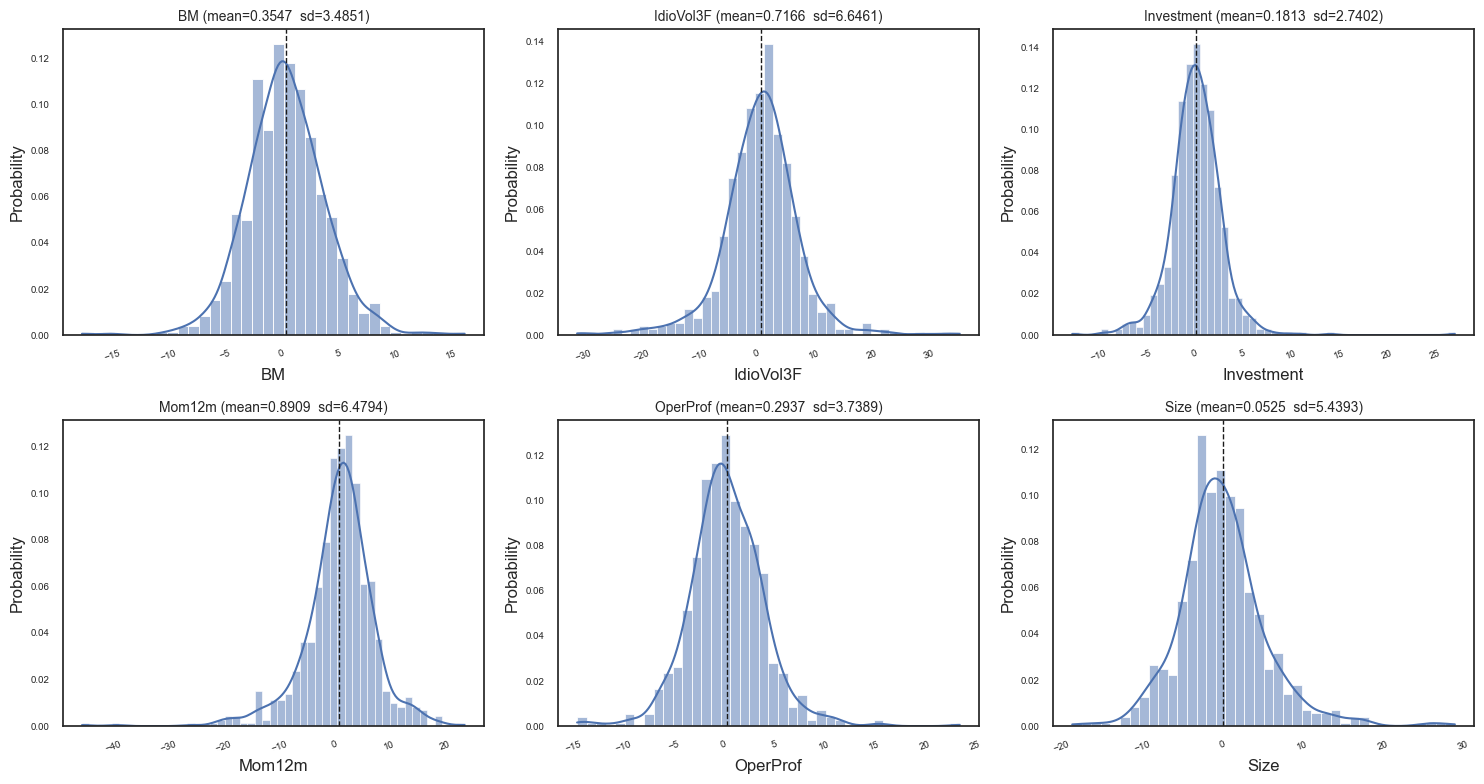

In [47]:
# plotting combined grid: histograms + KDE line for all factors monthly returns series
cols = osap_factor_returns.columns.tolist()
n, ncols = len(cols), 3
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    ax = axes[i]
    data = osap_factor_returns[col]
    if len(data) == 0:
        ax.set_visible(False)
        continue
    sns.histplot(data, kde=True, ax=ax, stat="probability", edgecolor=None)
    ax.set_title(f"{col} (mean={data.mean():.4f}  sd={data.std():.4f})", fontsize=10)
    ax.axvline(data.mean(), color='k', linestyle='--', linewidth=1)
    ax.tick_params(axis='x', rotation=20)
    ax.tick_params(labelsize=7)

# turning off any extra axes
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
grid_png = os.path.join(outputs_eda, "osap_factor_returns_distributions_grid.png")
fig.savefig(grid_png, dpi=300, bbox_inches='tight')
plt.show()

The Open Asset Pricing long–short factor returns display reasonable coverage (720 monthly observations) and meaningful cross-factor dispersion. Average monthly returns vary across factors, with $Mom12m$ and $OperProf$ showing higher means, while $Size$ and $Investment$ are smaller on average. Standard deviations differ substantially ($IdioVol3F$ and $Mom12m$ are the most volatile), and skew/kurtosis indicate mild asymmetry and fat tails for several series — a reminder to use robust covariance estimation and to test downside-aware utilities later.

From the distribution plots, the factor series are roughly unimodal but not perfectly Gaussian: many show heavier tails and occasional extreme values, especially $momentum$ and $idiosyncratic-vol$. This motivates 
- (a) using quantile-based discretization for BN structure learning,
- (b) preferring shrinkage or EWMA covariances for the decision node, and 
- (c) including regime-aware checks (HMM / yearwise analysis) because factor relationships may change over time. 

Next we’ll quantify pairwise relationships (Pearson and Spearman) and study how correlations evolve year-by-year to guide DBN / dynamic-BN choices.

### **Step 1.2- Correlation Analysis**

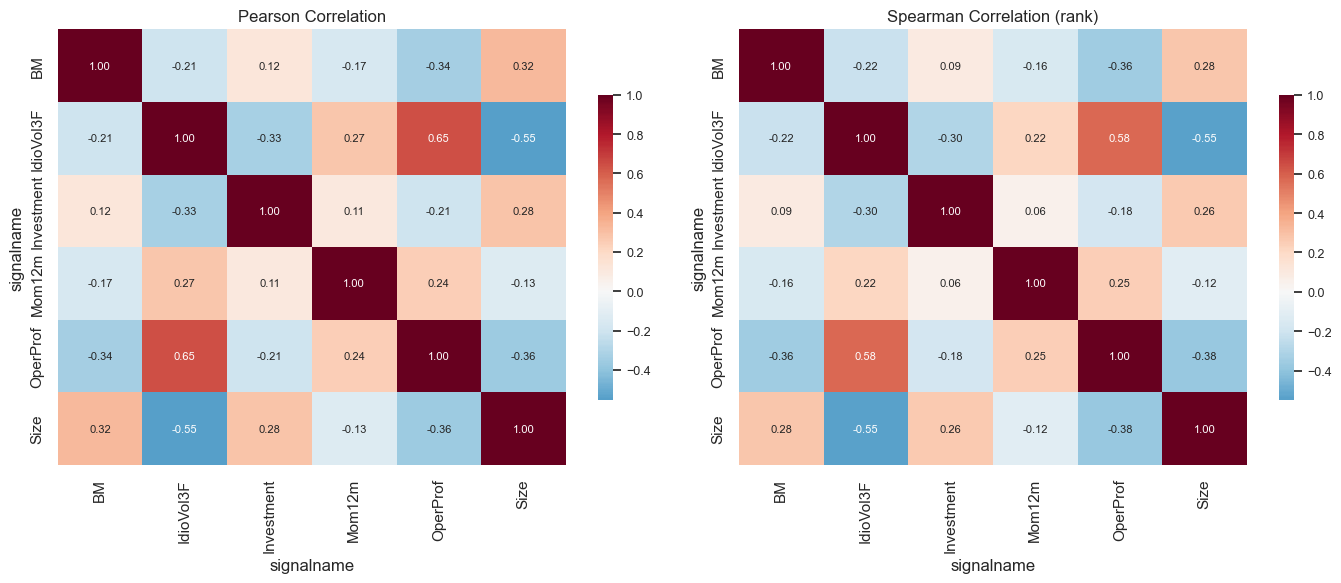

In [68]:
# computing spearman and pearson correlations to understand both linear and monotonic relationship between factors
pearson = osap_factor_returns.corr(method='pearson')
spearman = osap_factor_returns.corr(method='spearman')

# pretty-plotting
sns.set(style="white")
fig, ax = plt.subplots(1,2, figsize=(14,6))
sns.heatmap(pearson, annot=True,  annot_kws={"size": 8}, fmt=".2f", cmap='RdBu_r', center=0, ax=ax[0], cbar_kws={'shrink':0.7})
ax[0].set_title("Pearson Correlation")
sns.heatmap(spearman, annot=True,  annot_kws={"size": 8}, fmt=".2f", cmap='RdBu_r', center=0, ax=ax[1], cbar_kws={'shrink':0.7})
ax[1].set_title("Spearman Correlation (rank)")
# Set colorbar tick label size
ax[0].collections[0].colorbar.ax.tick_params(labelsize=9)
ax[1].collections[0].colorbar.ax.tick_params(labelsize=9)
plt.tight_layout()
plt.show()

In [49]:
# top pairs by absolute correlation (pearson)
pairs = (pearson.abs().where(np.triu(np.ones(pearson.shape), k=1).astype(bool))
         .stack().sort_values(ascending=False))
print("\nTop absolute Pearson correlations (factor pairs):")
display(pairs.head(10))


Top absolute Pearson correlations (factor pairs):


signalname  signalname
IdioVol3F   OperProf      0.646052
            Size          0.550902
OperProf    Size          0.357529
BM          OperProf      0.337683
IdioVol3F   Investment    0.328715
BM          Size          0.324749
Investment  Size          0.280103
IdioVol3F   Mom12m        0.274464
Mom12m      OperProf      0.242853
BM          IdioVol3F     0.209238
dtype: float64

In [50]:
# save correlation tables and heatmaps
pearson.to_csv(os.path.join(outputs_eda, "osap_correlation_pearson.csv"))
spearman.to_csv(os.path.join(outputs_eda, "osap_correlation_spearman.csv"))
fig.savefig(os.path.join(outputs_eda, "osap_correlation_heatmaps.png"), dpi=300, bbox_inches='tight')

The overall Pearson and Spearman heatmaps show generally moderate inter-factor relationships: most pairwise correlations lie in the low-to-mid range rather than being near $±1$. The strongest linear association is $IdioVol3F – OperProf (≈ 0.65)$, followed by $IdioVol3F – Size (≈ 0.55)$ and $OperProf – Size (≈ 0.36)$; other notable pairs include $BM – OperProf (~0.34)$ and $BM – Size (~0.32)$. Spearman (rank) correlations are directionally consistent with Pearson but slightly different in magnitude for some pairs (e.g., Momentum and idio-vol show a stronger rank relationship), which indicates that some dependencies are partly nonlinear or influenced by outliers. In short: the six chosen OpenAP factors are not collinear, but a few strong pairwise relationships (especially involving IdioVol3F, OperProf and Size) warrant special attention during BN structure selection and covariance estimation.

In [51]:
# Yearwise Correlations and Stability of factors

# prepare year index
osap_factors_yearly = osap_factor_returns.copy()
osap_factors_yearly['year'] = osap_factors_yearly.index.year

years = sorted(osap_factors_yearly['year'].unique())
n_years = len(years)
print("Years available:", years[0], "to", years[-1], f"({n_years} years)")

Years available: 1964 to 2023 (60 years)


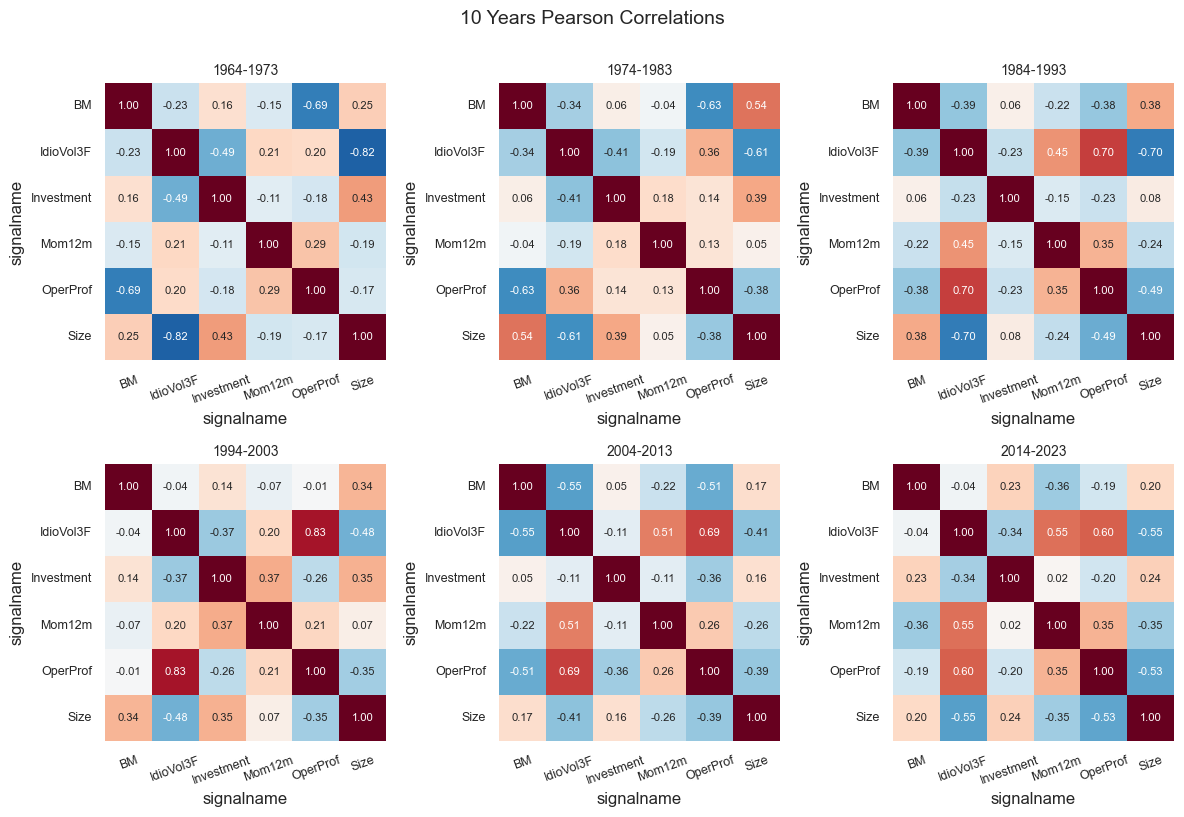

In [67]:
# computing period wise (10-Years Period) correlation matrices and heatmaps
year_corrs = {}
max_cols = osap_factor_returns.shape[1]
ncols = 3
nrows = math.ceil(n_years / ncols)
figsize = (4*ncols, 4*nrows)

fig = plt.figure(figsize=figsize)
for i, y in enumerate(range(years[0], years[-1]+1, 10)):
    sub = fig.add_subplot(nrows, ncols, i+1)
    dfy = osap_factors_yearly[osap_factors_yearly['year'].between(y, y+9)]
    dfy = dfy.drop(columns='year')
    yc = dfy.corr()
    year_corrs[f"{y}-{y+9}"] = yc
    sns.heatmap(yc, vmin=-1, vmax=1, center=0, fmt=".2f", cmap='RdBu_r', annot=True,  annot_kws={"size": 8}, cbar=False, ax=sub, cbar_kws={"labelsize": 9})
    sub.set_title(f"{y}-{y+9}", fontsize=10)
    
    # changing the ticks font for both y and x axis
    sub.tick_params(axis='x', rotation=20, labelsize=9)
    sub.tick_params(axis='y', rotation=0, labelsize=9)

plt.suptitle("10 Years Pearson Correlations", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.98])
plt.show()

# saving the figure
fig.savefig(os.path.join(outputs_eda, "osap_yearwise_correlation_multiples.png"), dpi=250, bbox_inches='tight')

The decade panels (1964–1973, 1974–1983, …, 2014–2023) reveal clear evolution in factor relationships. Mean absolute correlation per decade ranges from $≈0.27 (1994–2003)$ up to $≈0.34 (1984–1993)$, indicating periods of higher coupling and calmer decades with more independence. Visual inspection of the heatmaps shows the 1984–1993 and 2004–2013 blocks with relatively stronger co-movement among factors, whereas the 1994–2003 decade shows weaker average coupling. This multi-decade perspective suggests structural shifts in how style exposures interact (likely tied to macro/regime episodes), which argues for incorporating time-varying or regime-aware elements when learning BN structure (for example, re-learning structure on multi-year windows or using a DBN).

In [61]:
# stability metrics and top changing pairs between decades

# 1) Mean absolute correlation per period
stability_list = []
for period, mat in year_corrs.items():

    vals = mat.values
    iu = np.triu_indices_from(vals, k=1)
    upper = vals[iu]
    mean_abs = np.nanmean(np.abs(upper))
    mean_signed = np.nanmean(upper)
    stability_list.append({
        'period': period,
        'mean_abs_corr': mean_abs,
        'mean_signed_corr': mean_signed,
        'n_pairs': len(upper)
    })

stability_df = pd.DataFrame(stability_list).set_index('period')
stability_df.to_csv(os.path.join(outputs_eda, "osap_decade_mean_abs_correlation_summary.csv"))
display(stability_df)

,mean_abs_corr,mean_signed_corr,n_pairs
period,,,
1964-1973,0.303529,-0.100172,15
1974-1983,0.297542,-0.049655,15
1984-1993,0.336634,-0.067925,15
1994-2003,0.273030,0.062519,15
2004-2013,0.317209,-0.070319,15
2014-2023,0.316574,-0.025663,15


In [62]:
# 2) top changing pairs between consecutive periods
# sort periods in chronological order based on string like "1963-1972" -> use start year
def period_start(p):
    return int(p.split('-')[0])

period_keys = sorted(list(year_corrs.keys()), key=period_start)
top_movers_records = []

for i in range(1, len(period_keys)):
    p0 = period_keys[i-1]
    p1 = period_keys[i]
    C0 = year_corrs[p0].reindex(index=year_corrs[p0].index, columns=year_corrs[p0].columns)
    C1 = year_corrs[p1].reindex(index=year_corrs[p1].index, columns=year_corrs[p1].columns)

    # ensure same ordering of rows/cols
    common_vars = [c for c in C0.columns if c in C1.columns]
    C0 = C0.loc[common_vars, common_vars]
    C1 = C1.loc[common_vars, common_vars]

    # compute abs change matrix and extract upper triangle
    diff = (C1 - C0).abs()
    dif_vals = diff.where(np.triu(np.ones(diff.shape), k=1).astype(bool)).stack()
    dif_vals = dif_vals.dropna().sort_values(ascending=False)

    # top 10 movers for this pair of decades
    top_n = 10 if len(dif_vals) >= 10 else len(dif_vals)
    top = dif_vals.head(top_n)

    for pair, val in top.items():
        v1, v2 = pair
        top_movers_records.append({
            'from_period': p0,
            'to_period': p1,
            'pair': f"{v1} - {v2}",
            'abs_corr_change': val
        })

# convert to DataFrame and save
top_movers_df = pd.DataFrame(top_movers_records)
top_movers_df.to_csv(os.path.join(outputs_eda, "osap_decade_top_corr_pair_changes.csv"), index=False)
display(top_movers_df)

,from_period,to_period,pair,abs_corr_change
0,1964-1973,1974-1983,IdioVol3F - Mom12m,0.398607
1,1964-1973,1974-1983,Investment - OperProf,0.321556
2,1964-1973,1974-1983,Investment - Mom12m,0.297793
3,1964-1973,1974-1983,BM - Size,0.296731
4,1964-1973,1974-1983,Mom12m - Size,0.242758
5,1964-1973,1974-1983,OperProf - Size,0.212854
6,1964-1973,1974-1983,IdioVol3F - Size,0.202619
7,1964-1973,1974-1983,IdioVol3F - OperProf,0.160841
8,1964-1973,1974-1983,Mom12m - OperProf,0.151141
9,1964-1973,1974-1983,BM - IdioVol3F,0.116096


In [63]:
# 3) printing a concise summary for the most recent decade transition
if len(period_keys) >= 2:
    last_from, last_to = period_keys[-2], period_keys[-1]
    print(f"\nTop movers from {last_from} -> {last_to}:")
    display(top_movers_df[top_movers_df['from_period']==last_from].head(10))


Top movers from 2004-2013 -> 2014-2023:


,from_period,to_period,pair,abs_corr_change
40,2004-2013,2014-2023,BM - IdioVol3F,0.506191
41,2004-2013,2014-2023,BM - OperProf,0.317131
42,2004-2013,2014-2023,IdioVol3F - Investment,0.237450
43,2004-2013,2014-2023,BM - Investment,0.180870
44,2004-2013,2014-2023,Investment - OperProf,0.155963
45,2004-2013,2014-2023,OperProf - Size,0.143184
46,2004-2013,2014-2023,BM - Mom12m,0.138596
47,2004-2013,2014-2023,IdioVol3F - Size,0.136719
48,2004-2013,2014-2023,Investment - Mom12m,0.129584
49,2004-2013,2014-2023,IdioVol3F - OperProf,0.094490


The stability summary shows modest but meaningful shifts across decades; mean absolute correlation moves between $~0.273$ and $~0.337$. The largest recent mover is the transition $2004–2013 → 2014–2023$, where the top absolute change is $BM – IdioVol3F (Δ ≈ 0.506)$ — a very large change indicating that the relationship between value and idiosyncratic volatility flipped materially in the most recent decade. Other notable movers for that transition include $BM – OperProf (Δ ≈ 0.317)$ and $IdioVol3F – Investment (Δ ≈ 0.237)$. Practically, this implies we should 
- (a) consider retraining or re-estimating BN structure on a decadal cadence as a baseline, and 
- (b) trigger ad-hoc re-learning when mean-abs-correlation spikes (e.g., the ~0.34 decade) or when a large pairwise shift (like the 0.5 jump above) occurs — those events signal structural regime change and could invalidate a static causal graph.

### **Step 1.3- Time Series Plots**

### **Step 1.4- Autocorrelation**

### **Step 1.5- Information Coefficient (IC) and Stationarity Tests**